In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
filename = '/home/lacrio/Downloads/transfer_13662390_files_314b8ad0/T2_snowfox_lf.dat'

df = pd.read_csv(filename, skiprows=[0, 2,3])
df.columns

Index(['TIMESTAMP', 'RECORD', 'Batt_Min', 'PTemp_Avg', 'Tair_1_Avg',
       'Tair_2_Avg', 'Hum_1_Avg', 'Hum_2_Avg', 'SWin_Avg', 'SWout_Avg',
       'LWin_Avg', 'LWout_Avg', 'CNR4TC_Avg', 'LWinCor_Avg', 'LWoutCor_Avg',
       'Wspeed', 'Wdir', 'Wspeed_Max', 'DT_raw', 'Q', 'TCDT', 'Snow_Depth',
       'Press_Avg'],
      dtype='object')

In [3]:
vars_sel = ['TIMESTAMP', 'Tair_2_Avg', 'Hum_2_Avg', 'SWin_Avg', 'SWout_Avg', 'LWinCor_Avg', 'LWoutCor_Avg',
            'Wspeed', 'Wdir', 'Snow_Depth', 'Press_Avg']

df_sel = df[vars_sel]
# Parse datetime and adjust offset (+3 hours)
df_sel["datetime"] = pd.to_datetime(df_sel["TIMESTAMP"]) 
df_sel = df_sel.set_index("datetime")

df_sel = df_sel.loc['2023-08-18':'2023-08-24']

/tmp/ipykernel_6160/2694122268.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sel["datetime"] = pd.to_datetime(df_sel["TIMESTAMP"])


In [4]:
# File path to EddyPro full output file
file_path = "/home/lacrio/Downloads/transfer_13662390_files_314b8ad0/eddypro_csat_full_output_2026-10-08T083750_exp.csv"

# Load CSV ignoring top metadata header rows and treating -9999 as missing values
df = pd.read_csv(file_path, sep=",", skiprows=[0, 2], na_values=-9999)

# Inspect column names
print(df.columns)

Index(['filename', 'date', 'time', 'DOY', 'daytime', 'file_records',
       'used_records', 'Tau', 'qc_Tau', 'H',
       ...
       'ts_var', 'co2_var', 'h2o_var', 'w/ts_cov', 'w/co2_cov', 'w/h2o_cov',
       'u_mean', 'v_mean', 'w_mean', 'ts_mean'],
      dtype='object', length=114)


In [5]:
# Select target micrometeorological variables
df_sel_eddy = df[["date", "time", "H", "LE", "air_temperature", 'air_pressure', "RH", "wind_speed", "wind_dir"]].copy()


# Construct datetime index and apply time zone shift (+3 hours)
df_sel_eddy["datetime"] = pd.to_datetime(df_sel_eddy["date"] + " " + df_sel_eddy["time"])
df_sel_eddy = df_sel_eddy.set_index("datetime").drop(columns=["date", "time"]).resample("1h").mean()
df_sel_eddy

,H,LE,air_temperature,air_pressure,RH,wind_speed,wind_dir
datetime,,,,,,,
2023-08-18 00:00:00,-74.23790,-0.560993,280.9550,73687.90,59.60950,1.745100,85.61770
2023-08-18 01:00:00,-58.88075,5.804810,280.5295,73679.85,72.67340,1.595065,111.35575
2023-08-18 02:00:00,-83.92820,-9.094605,280.5100,73673.50,86.43345,1.335736,179.32750
2023-08-18 03:00:00,-64.31990,-9.001115,280.6055,73668.25,86.46215,0.992816,150.40445
2023-08-18 04:00:00,-58.30555,-11.789285,280.6745,73671.70,87.71760,1.159784,58.81815
...,...,...,...,...,...,...,...
2023-08-25 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-08-25 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-08-25 22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Select desired variables from each dataset
cols_tower = ['SWin_Avg', 'SWout_Avg', 'LWinCor_Avg', 'LWoutCor_Avg']
cols_eddy = ["H", "LE"]

# Merge datasets on datetime index
df_merged = pd.merge(df_sel[cols_tower], df_sel_eddy[cols_eddy], on="datetime", how="inner").loc['2023-08-18':'2023-08-24']

df_merged

,SWin_Avg,SWout_Avg,LWinCor_Avg,LWoutCor_Avg,H,LE
datetime,,,,,,
2023-08-18 00:00:00,-2.560577,5.368653,292.2883,325.0677,-74.23790,-0.560993
2023-08-18 01:00:00,0.185919,3.551950,302.6955,325.2170,-58.88075,5.804810
2023-08-18 02:00:00,-0.302615,1.084664,307.3164,325.8494,-83.92820,-9.094605
2023-08-18 03:00:00,-0.468870,1.171565,305.7386,325.6292,-64.31990,-9.001115
2023-08-18 04:00:00,0.045711,0.735096,320.9299,325.9255,-58.30555,-11.789285
...,...,...,...,...,...,...
2023-08-24 19:00:00,-1.592874,-0.312306,303.5416,331.7068,-74.75720,-27.439200
2023-08-24 20:00:00,-1.213692,-0.217152,316.5309,331.6024,NaN,NaN
2023-08-24 21:00:00,-1.344232,-0.017114,354.0774,332.7958,NaN,NaN


In [7]:
# 1. Calculate Net Radiation and Surface Energy Balance terms
df_merged["Rn"] = (df_merged["SWin_Avg"] - df_merged["SWout_Avg"]) + (df_merged["LWinCor_Avg"] - df_merged["LWoutCor_Avg"])
df_merged["SEB_Consumed"] = df_merged["H"] + df_merged["LE"]
df_merged["SEB_Residual"] = df_merged["Rn"] - df_merged["SEB_Consumed"]
df_merged

,SWin_Avg,SWout_Avg,LWinCor_Avg,LWoutCor_Avg,H,LE,Rn,SEB_Consumed,SEB_Residual
datetime,,,,,,,,,
2023-08-18 00:00:00,-2.560577,5.368653,292.2883,325.0677,-74.23790,-0.560993,-40.708630,-74.798893,34.090263
2023-08-18 01:00:00,0.185919,3.551950,302.6955,325.2170,-58.88075,5.804810,-25.887531,-53.075940,27.188409
2023-08-18 02:00:00,-0.302615,1.084664,307.3164,325.8494,-83.92820,-9.094605,-19.920279,-93.022805,73.102526
2023-08-18 03:00:00,-0.468870,1.171565,305.7386,325.6292,-64.31990,-9.001115,-21.531035,-73.321015,51.789980
2023-08-18 04:00:00,0.045711,0.735096,320.9299,325.9255,-58.30555,-11.789285,-5.684986,-70.094835,64.409849
...,...,...,...,...,...,...,...,...,...
2023-08-24 19:00:00,-1.592874,-0.312306,303.5416,331.7068,-74.75720,-27.439200,-29.445768,-102.196400,72.750632
2023-08-24 20:00:00,-1.213692,-0.217152,316.5309,331.6024,NaN,NaN,-16.068040,NaN,NaN
2023-08-24 21:00:00,-1.344232,-0.017114,354.0774,332.7958,NaN,NaN,19.954482,NaN,NaN


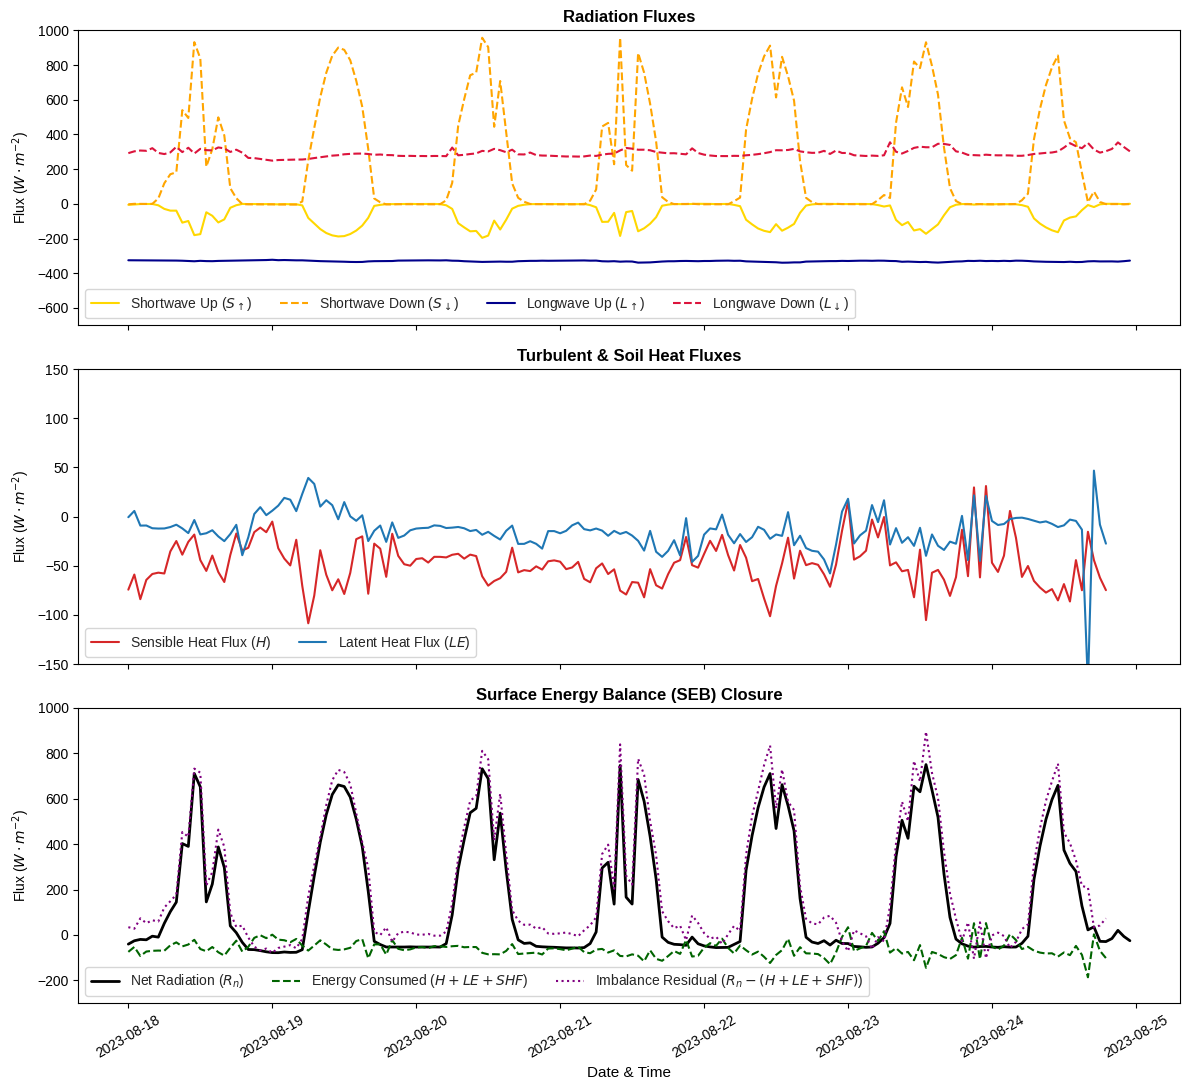

In [ ]:
# 2. Figure Setup with 3 Subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)

# --- Subplot 1: Radiation Fluxes ---
# Intercambiamos los labels entre SDn y SUp, y entre LDnCo y LUpCo para ajustar a los datos reales
ax1.plot(
    df_merged.index,
    -df_merged["SWout_Avg"],
    label="Shortwave Up ($S_{\\uparrow}$)",
    color="gold",
    linewidth=1.5,
)
ax1.plot(
    df_merged.index,
    df_merged["SWin_Avg"],
    label="Shortwave Down ($S_{\\downarrow}$)",
    color="orange",
    linestyle="--",
    linewidth=1.5,
)
ax1.plot(
    df_merged.index,
    -df_merged["LWoutCor_Avg"],
    label="Longwave Up ($L_{\\uparrow}$)",
    color="darkblue",
    linewidth=1.5,
)
ax1.plot(
    df_merged.index,
    df_merged["LWinCor_Avg"],
    label="Longwave Down ($L_{\\downarrow}$)",
    color="crimson",
    linestyle="--",
    linewidth=1.5,
)
ax1.set_ylabel("Flux ($W\\cdot m^{-2}$)", fontsize=10)
ax1.set_title("Radiation Fluxes", fontsize=12, fontweight="bold")
ax1.set_ylim(-700, 1000)
ax1.legend(loc="lower left", frameon=True, ncol=4)


# --- Subplot 2: Turbulent & Soil Heat Fluxes ---
ax2.plot(
    df_merged.index,
    df_merged["H"],
    label="Sensible Heat Flux ($H$)",
    color="tab:red",
    linewidth=1.5,
)
ax2.plot(
    df_merged.index,
    df_merged["LE"],
    label="Latent Heat Flux ($LE$)",
    color="tab:blue",
    linewidth=1.5,
)

ax2.set_ylabel("Flux ($W\\cdot m^{-2}$)", fontsize=10)
ax2.set_ylim(-150, 150)
ax2.set_title("Turbulent & Soil Heat Fluxes", fontsize=12, fontweight="bold")
ax2.legend(loc="lower left", frameon=True, ncol=3)

# --- Subplot 3: Surface Energy Balance (SEB) ---
ax3.plot(
    df_merged.index,
    df_merged["Rn"],
    label="Net Radiation ($R_n$)",
    color="black",
    linewidth=2,
)
ax3.plot(
    df_merged.index,
    df_merged["SEB_Consumed"],
    label="Energy Consumed ($H + LE + SHF$)",
    color="darkgreen",
    linestyle="--",
    linewidth=1.5,
)
ax3.plot(
    df_merged.index,
    df_merged["SEB_Residual"],
    label="Imbalance Residual ($R_n - (H+LE)$)",
    color="purple",
    linestyle=":",
    linewidth=1.5,
)
ax3.set_ylabel("Flux ($W\\cdot m^{-2}$)", fontsize=10)
ax3.set_ylim(-300, 1000)
ax3.set_xlabel("Date & Time", fontsize=11)
ax3.set_title(
    "Surface Energy Balance (SEB) Closure", fontsize=12, fontweight="bold"
)
ax3.legend(loc="lower left", frameon=True, ncol=3)

plt.xticks(rotation=30)
plt.tight_layout()

